# Wine Quality Segmentation & Predictive Modeling

> Portfolio analysis ? Spanish ? [Abrir dashboard interactivo](./index.html)

## tl;dr

- El conjunto contiene **5.320 vinos** y **11 variables qu?micas** ya estandarizadas.
- Antes de modelar, los vinos se comparan dentro de tres segmentos: **tintos no dulces** (1.269), **blancos no dulces** (1.912) y **candidatos dulces / late harvest** (2.139).
- El mejor resultado de prueba fue un **Random Forest para tintos no dulces** (R? = 0,4518; RMSE = 0,7189). La qu?mica explica parte de la calidad, pero no sustituye la cata ni el contexto de producci?n.
- El objetivo no es declarar una receta universal de ?buen vino?, sino mostrar por qu? la interpretaci?n de las variables cambia entre estilos.

Este notebook conserva el an?lisis reproducible y el [dashboard](./index.html) traduce sus ideas principales a una experiencia de exploraci?n.


In [1]:
# Setup: imports, parameters and source data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 42
DATA_PATH = "winequality_cleaned.csv"

# El CSV conserva un ?ndice de exportaci?n; se elimina por nombre, no por posici?n.
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[column for column in df.columns if column.startswith("Unnamed")])


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\kinga\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## Context & Methods

### Question

?Qu? tan lejos puede llegar una predicci?n de calidad basada solamente en qu?mica, y por qu? conviene comparar perfiles de vino dentro de segmentos antes de entrenar un modelo?

Una lectura r?pida del dataset podr?a llevar a entrenar un ?nico modelo para todos los vinos. Ese enfoque es t?cnicamente posible, pero metodol?gicamente incompleto: un blanco no dulce, un tinto y un perfil con az?car residual alto no necesariamente compiten bajo la misma l?gica de calidad.

El flujo de trabajo tiene cinco etapas:

1. Cargar y revisar el dataset limpio.
2. Crear segmentos anal?ticos con tipo, az?car residual y acidez estructural.
3. Entrenar regresiones por segmento y evaluarlas en datos de prueba.
4. Comparar correlaciones y perfiles de vinos bien evaluados dentro de cada categor?a.
5. Resumir el espacio qu?mico con clustering e interpretar los grupos con cautela.

### Key assumptions

- `quality` y las variables qu?micas est?n estandarizadas; los resultados describen calidad **relativa** dentro de este conjunto.
- ?Candidato dulce / late harvest? es una hip?tesis anal?tica de dulzor frente a acidez, no una etiqueta comercial ni una denominaci?n de origen.
- El dataset no contiene cata, terroir, a?ada, marca, m?todo de elaboraci?n, color, presi?n o CO?. Por tanto, no se infieren rosados ni espumantes y no se hacen afirmaciones causales.
- La evaluaci?n se hace con una partici?n train/test fija (`RANDOM_STATE = 42`) para que el notebook sea reproducible.


## Data

### 1. Load and validate inputs

El archivo fuente es `winequality_cleaned.csv`. Antes de segmentar o modelar, verificamos el tama?o del conjunto, la cobertura de valores y la composici?n por tipo declarado. Las variables num?ricas ya vienen estandarizadas; por eso se leen como posiciones relativas dentro del conjunto y no como unidades de laboratorio.


In [2]:
# Data-quality snapshot: bounded and reader-friendly
numeric_columns = df.select_dtypes(include="number").columns

data_audit = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "numeric_features": [len(numeric_columns) - 1],  # excludes the quality target
    "missing_values": [int(df.isna().sum().sum())],
    "duplicate_rows": [int(df.duplicated().sum())],
})

display(data_audit)
display(df["type"].value_counts().rename("rows").to_frame())
display(df.head(3))
display(df[numeric_columns].describe().T[["mean", "std", "min", "max"]].round(3))


,rows,columns,numeric_features,missing_values,duplicate_rows
0,5320,13,11,0,0


,rows
type,
white,3961
red,1359


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,type
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,-0.904497,red
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,-0.904497,red
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,-0.904497,red


,mean,std,min,max
fixed_acidity,-0.0,1.0,-2.588,6.582
volatile_acidity,0.0,1.0,-1.570,7.346
citric_acid,0.0,1.0,-2.165,9.117
residual_sugar,0.0,1.0,-0.989,13.501
chlorides,0.0,1.0,-1.294,15.038
free_sulfur_dioxide,0.0,1.0,-1.631,14.546
total_sulfur_dioxide,0.0,1.0,-1.904,5.741
density,-0.0,1.0,-2.504,14.989
ph,-0.0,1.0,-3.147,4.897
sulphates,0.0,1.0,-2.093,9.795


## 1. Segmentación: por qué no conviene mezclar todos los vinos

El dataset original solo identifica dos tipos: `red` y `white`. 
Aquí es donde saber de vinos entra en acción, pues no podemos limitarnos a definir la calidad de los vinos solo por estas dos categorías. No tenemos etiquetas de rosado, espumante, late harvest, vermouth, vino fortificado, etc. Por ello, si nos limitamos a solo considerar "vino blanco bueno" no sabemos cuánta azúcar contiene, y eso juega un rol fundamental: aspectos como la acidez o la densidad esperables de un late harvest son radicalmente diferentes a los de un chardonnay ligero. Aun así, los datos químicos permiten construir una segmentación prudente para evitar una conclusión demasiado general separando los dulces. Sin embargo, no hay manera de definir con precisión otras variedades como rosados o espumantes, pues aspectos químicos como el CO2 no se encuentran analizados en el dataset.

La idea central es separar vinos que probablemente se evalúan con criterios distintos:

- `red_non_sweet`: vinos tintos que no aparecen como candidatos dulces.
- `white_non_sweet`: vinos blancos que no aparecen como candidatos dulces.
- `sweet_or_late_harvest_candidate`: vinos con azucar residual alto en relacion con su acidez.

Para aproximar esa tercera categoria creamos un indicador simple:

`sweetness_acidity_score = residual_sugar - acidity_index`

El `acidity_index` combina `fixed_acidity` y `citric_acid`, dos señales más cercanas a estructura y frescor. No usamos `volatile_acidity` en este índice porque suele representar acidez volátil, que puede asociarse a defectos o desviaciones, no necesariamente a la acidez que equilibra dulzor.

Esta segmentación no pretende afirmar que todos los vinos dulces sean late harvest. Es una hipótesis analítica: nos permite separar vinos cuyo perfil de azúcar/acidez sugiere que no deberían evaluarse con la misma vara que un blanco seco o un tinto.

In [3]:
target = "quality"
base_chemical_features = [col for col in df.columns if col not in [target, "type"]]

# Indice simple de acidez estructural. Todas estas variables ya estan estandarizadas.
df["acidity_index"] = df[["fixed_acidity", "citric_acid"]].mean(axis=1)
df["sweetness_acidity_score"] = df["residual_sugar"] - df["acidity_index"]

# Division a la mitad: alto azucar residual y alto dulzor relativo a acidez.
sugar_threshold = df["residual_sugar"].median()
sweetness_acidity_threshold = df["sweetness_acidity_score"].median()

df["sweet_candidate"] = (
    (df["residual_sugar"] >= sugar_threshold)
    & (df["sweetness_acidity_score"] >= sweetness_acidity_threshold)
)

df["wine_segment"] = np.select(
    [
        df["sweet_candidate"],
        df["type"].eq("red"),
        df["type"].eq("white"),
    ],
    [
        "sweet_or_late_harvest_candidate",
        "red_non_sweet",
        "white_non_sweet",
    ],
    default="unknown"
)

segment_summary = pd.crosstab(df["wine_segment"], df["type"], margins=True)
segment_summary

type,red,white,All
wine_segment,,,
red_non_sweet,1269,0,1269
sweet_or_late_harvest_candidate,90,2049,2139
white_non_sweet,0,1912,1912
All,1359,3961,5320


### Lectura del mapa dulzor/acidez

El siguiente grafico muestra por que creamos una categoria dulce candidata. En el eje vertical aparece `residual_sugar`; en el eje horizontal, el indice de acidez estructural. Los vinos con mas azucar residual y mayor dulzor relativo a su acidez se separan visualmente del resto.

Para un lector no tecnico, esta visualizacion responde una pregunta concreta: **hay vinos que, por su balance quimico, no deberian competir directamente contra blancos secos o tintos tradicionales?** Si la respuesta visual es si, entonces segmentar antes de modelar no es un capricho, sino una forma de reducir sesgo.

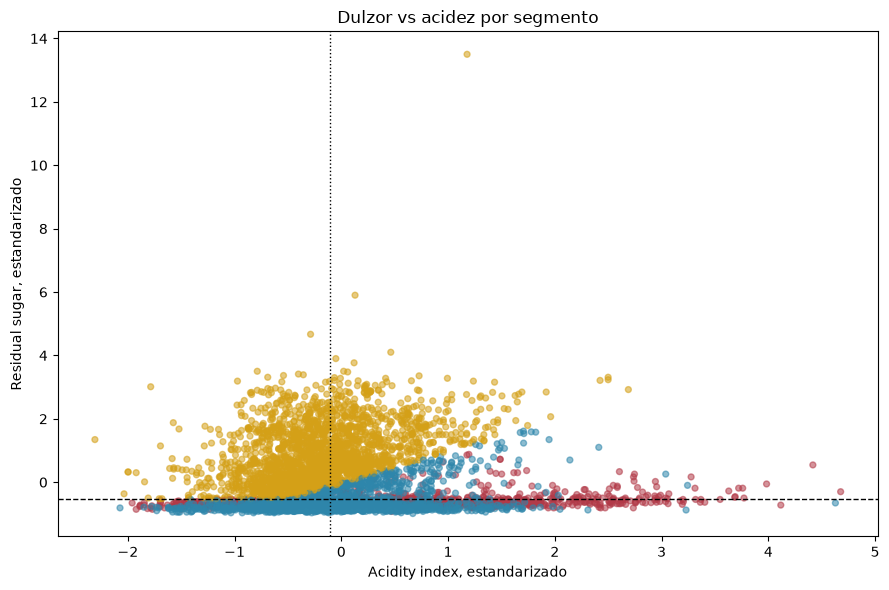

In [4]:
colors = df["wine_segment"].map({
    "red_non_sweet": "#B23A48",
    "white_non_sweet": "#2E86AB",
    "sweet_or_late_harvest_candidate": "#D4A017",
})

plt.figure(figsize=(9, 6))
plt.scatter(
    df["acidity_index"],
    df["residual_sugar"],
    c=colors,
    alpha=0.55,
    s=18
)
plt.axhline(sugar_threshold, color="black", linewidth=1, linestyle="--")
plt.axvline(df["acidity_index"].median(), color="black", linewidth=1, linestyle=":")
plt.title("Dulzor vs acidez por segmento")
plt.xlabel("Acidity index, estandarizado")
plt.ylabel("Residual sugar, estandarizado")
plt.tight_layout()
plt.show()

## 2. Categorías que no podemos afirmar: rosados y espumantes

Una parte importante de un análisis profesional es saber dónde detenerse. Con este dataset no es responsable crear una categoría formal de rosados o espumantes.

Para rosados necesitaríamos información de color, intensidad fenólica, método de elaboración o etiquetas originales. Podríamos hipotetizar que los tintos con menor tanino y mayor acidez podrían ser considerados rosados, o que como mínimo deberían evaluarse de manera diferente, pero el dataset no contiene taninos ni medidas directas de color.

Para espumantes necesitaríamos variables como presión, CO2, método de fermentación, azúcar de dosage o una etiqueta de estilo. Las variables actuales no ofrecen maneras sólidas para identificar burbujas ni método de elaboración.

Por eso los grupos del análisis serán tres: tintos no dulces, blancos no dulces y candidatos dulces o late harvest. Es preferible explicar una limitación con claridad antes que inventar una categoría atractiva pero débil.

## 3. Modelos de regresion: medir calidad sin ignorar el segmento

Primero usamos modelos de regresion para estimar `quality` como valor continuo. Esta etapa sirve para responder: **que tan predecible es la calidad usando solo quimica?**

Medimos el desempeno con tres metricas:

- **MAE:** error promedio absoluto. Es facil de leer: cuanto se equivoca el modelo en promedio.
- **RMSE:** penaliza mas los errores grandes. Es util cuando los errores extremos importan.
- **R2:** proporcion de variabilidad explicada por el modelo. Un R2 bajo indica que la quimica disponible explica solo una parte de la calidad.

La comparacion relevante se hace en test, no en train, porque test simula vinos que el modelo no vio. En este dataset es esperable que la prediccion tenga un limite natural: la calidad del vino tambien depende de cata, proceso, origen, estilo, marca, criterio humano y variables que no estan en la tabla.

In [5]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    """Entrena un modelo de regresion y devuelve sus metricas en train y test."""
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "model": model_name,
        "train_MAE": mean_absolute_error(y_train, train_pred),
        "test_MAE": mean_absolute_error(y_test, test_pred),
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
    }


def make_random_forest():
    return RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

### Por que entrenar modelos por segmento

Entrenamos modelos dentro de cada categoria para evitar que un patron dominante oculte patrones especificos. Si mezclamos todos los vinos, el modelo puede aprender una regla promedio que funciona razonablemente, pero que no representa bien a ningun estilo en particular.

Comparamos dos familias de modelos:

- **Regresion lineal:** interpretable y simple. Sirve como linea base.
- **Random Forest:** captura relaciones no lineales e interacciones entre variables. Suele ser mas fuerte para datos quimicos con efectos combinados.

El nombre `model1_Quality` se reserva para los Random Forest por segmento, porque en las pruebas previas fue el enfoque mas efectivo. La regresion lineal se conserva como benchmark: si un modelo simple funciona bien en algun segmento, eso tambien es informacion.

In [6]:
model_features = base_chemical_features.copy()
model1_Quality = {}
all_model_results = []

for segment_name, segment_df in df.groupby("wine_segment"):
    X = segment_df[model_features]
    y = segment_df[target]

    if len(segment_df) < 80:
        print(f"Segmento saltado por tener pocos datos: {segment_name} ({len(segment_df)} filas)")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    linear_model = LinearRegression()
    random_forest_model = make_random_forest()

    linear_results = evaluate_regression_model(
        "Linear Regression",
        linear_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    rf_results = evaluate_regression_model(
        "Random Forest",
        random_forest_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    linear_results["wine_segment"] = segment_name
    linear_results["rows"] = len(segment_df)
    rf_results["wine_segment"] = segment_name
    rf_results["rows"] = len(segment_df)

    all_model_results.extend([linear_results, rf_results])
    model1_Quality[segment_name] = random_forest_model

model_results = pd.DataFrame(all_model_results)
metric_cols = ["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "train_R2", "test_R2"]
model_results[metric_cols] = model_results[metric_cols].round(4)

model_results.sort_values(["wine_segment", "test_RMSE"])

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,wine_segment,rows
1,Random Forest,0.2083,0.5626,0.2731,0.7189,0.9111,0.4518,red_non_sweet,1269
0,Linear Regression,0.5656,0.6020,0.7277,0.7663,0.3689,0.3771,red_non_sweet,1269
3,Random Forest,0.2209,0.5920,0.2884,0.7834,0.9141,0.3801,sweet_or_late_harvest_candidate,2139
2,Linear Regression,0.6339,0.6543,0.8067,0.8555,0.3275,0.2608,sweet_or_late_harvest_candidate,2139
5,Random Forest,0.2401,0.6300,0.3123,0.8313,0.9110,0.3429,white_non_sweet,1912
4,Linear Regression,0.6652,0.6620,0.8645,0.8730,0.3180,0.2752,white_non_sweet,1912


### Como leer la tabla de modelos

La tabla anterior compara regresion lineal y Random Forest dentro de cada categoria. Lo importante no es solo encontrar el menor error, sino observar si el desempeno cambia por tipo de vino.

Si un segmento tiene peor R2 o mayor RMSE, no significa automaticamente que esos vinos sean peores. Puede significar que su calidad depende de factores no observados en el dataset. Esta diferencia es clave para lectura de inversion: hay estilos donde la quimica disponible predice mejor, y estilos donde se necesita mas informacion antes de tomar decisiones.

In [7]:
best_model_by_segment = (
    model_results
    .sort_values("test_RMSE")
    .groupby("wine_segment", as_index=False)
    .first()
)

best_model_by_segment[["wine_segment", "model", "rows", "test_MAE", "test_RMSE", "test_R2"]]

,wine_segment,model,rows,test_MAE,test_RMSE,test_R2
0,red_non_sweet,Random Forest,1269,0.5626,0.7189,0.4518
1,sweet_or_late_harvest_candidate,Random Forest,2139,0.5920,0.7834,0.3801
2,white_non_sweet,Random Forest,1912,0.6300,0.8313,0.3429


## 4. Importancia de variables: que usa el modelo para predecir

La importancia de variables del Random Forest muestra que factores ayudan mas a reducir error predictivo dentro de cada segmento. No debe confundirse con correlacion.

Una variable puede tener baja correlacion lineal con `quality`, pero alta importancia en Random Forest si su efecto es no lineal o si depende de otra variable. Por ejemplo, el azucar residual puede ser positivo en un estilo, irrelevante en otro y negativo si rompe el equilibrio del vino.

Esta tabla se debe leer como una senal de modelado: **que variables necesita mirar el algoritmo para explicar calidad dentro de cada categoria?**

In [8]:
feature_importances = []

for segment_name, fitted_model in model1_Quality.items():
    segment_importance = pd.DataFrame({
        "wine_segment": segment_name,
        "feature": model_features,
        "importance": fitted_model.feature_importances_
    })
    feature_importances.append(segment_importance)

feature_importance_by_segment = pd.concat(feature_importances, ignore_index=True)

feature_importance_by_segment.sort_values(
    ["wine_segment", "importance"],
    ascending=[True, False]
).round(4)

,wine_segment,feature,importance
10,red_non_sweet,alcohol,0.2917
9,red_non_sweet,sulphates,0.1325
1,red_non_sweet,volatile_acidity,0.1298
6,red_non_sweet,total_sulfur_dioxide,0.0682
8,red_non_sweet,ph,0.0609
4,red_non_sweet,chlorides,0.0577
3,red_non_sweet,residual_sugar,0.0554
7,red_non_sweet,density,0.0535
0,red_non_sweet,fixed_acidity,0.0516
2,red_non_sweet,citric_acid,0.0508


### Que nos dice la comparacion buenos vs resto

La tabla anterior compara el promedio de cada variable entre los mejores vinos de cada segmento y el resto del mismo segmento. Esta es una lectura mas directa que la importancia de modelo: muestra hacia donde se desplaza la quimica cuando miramos los vinos mejor evaluados.


## 5. Correlaciones separadas por categoria

La correlacion mide la relacion lineal entre una variable quimica y `quality`. En un analisis comun podriamos calcular una sola correlacion global, pero aqui eso seria una simplificacion peligrosa.

Si mezclamos tintos, blancos y candidatos dulces, el resultado puede esconder que una misma variable cambia de significado segun el estilo. El azucar residual, la densidad, el alcohol o el dioxido de azufre total pueden tener lecturas distintas entre categorias.

Por eso calculamos correlaciones por segmento. La pregunta no es solamente: **que variable se relaciona con calidad?** La pregunta correcta es: **en que tipo de vino se relaciona, y en que direccion?**

In [9]:
correlation_rows = []

for segment_name, segment_df in df.groupby("wine_segment"):
    correlations = (
        segment_df[model_features + [target]]
        .corr(numeric_only=True)[target]
        .drop(target)
    )

    for feature, correlation in correlations.items():
        correlation_rows.append({
            "wine_segment": segment_name,
            "feature": feature,
            "correlation_with_quality": correlation,
            "abs_correlation": abs(correlation),
            "direction": "positive" if correlation > 0 else "negative"
        })

correlations_by_segment = pd.DataFrame(correlation_rows)

correlations_by_segment.sort_values(
    ["wine_segment", "abs_correlation"],
    ascending=[True, False]
).round(4)

,wine_segment,feature,correlation_with_quality,abs_correlation,direction
10,red_non_sweet,alcohol,0.5041,0.5041,positive
1,red_non_sweet,volatile_acidity,-0.3833,0.3833,negative
9,red_non_sweet,sulphates,0.2433,0.2433,positive
2,red_non_sweet,citric_acid,0.2132,0.2132,positive
6,red_non_sweet,total_sulfur_dioxide,-0.1921,0.1921,negative
7,red_non_sweet,density,-0.1835,0.1835,negative
4,red_non_sweet,chlorides,-0.1356,0.1356,negative
3,red_non_sweet,residual_sugar,0.1159,0.1159,positive
0,red_non_sweet,fixed_acidity,0.1084,0.1084,positive
5,red_non_sweet,free_sulfur_dioxide,-0.0571,0.0571,negative


In [10]:
correlation_matrix_by_segment = correlations_by_segment.pivot(
    index="feature",
    columns="wine_segment",
    values="correlation_with_quality"
)

correlation_matrix_by_segment.round(4)

wine_segment,red_non_sweet,sweet_or_late_harvest_candidate,white_non_sweet
feature,,,
alcohol,0.5041,0.4848,0.4295
chlorides,-0.1356,-0.2725,-0.1728
citric_acid,0.2132,0.0262,0.0233
density,-0.1835,-0.3795,-0.3787
fixed_acidity,0.1084,-0.1131,-0.1604
free_sulfur_dioxide,-0.0571,-0.0603,0.1758
ph,-0.0393,0.0524,0.1436
residual_sugar,0.1159,-0.1330,0.0086
sulphates,0.2433,-0.0463,0.1244


### Lectura ejecutiva de la matriz de correlaciones

La matriz anterior permite comparar rapidamente una misma variable entre categorias. Un valor positivo indica que la variable tiende a subir cuando sube `quality`; un valor negativo indica lo contrario. Valores cercanos a cero sugieren poca relacion lineal directa.

Lo mas relevante para el proyecto no es encontrar una variable universal, sino observar diferencias. Si una variable cambia de signo entre categorias, eso confirma que un modelo global puede mezclar senales contradictorias.

In [11]:
top_correlations_by_segment = (
    correlations_by_segment
    .sort_values(["wine_segment", "abs_correlation"], ascending=[True, False])
    .groupby("wine_segment")
    .head(5)
)

top_correlations_by_segment.round(4)

,wine_segment,feature,correlation_with_quality,abs_correlation,direction
10,red_non_sweet,alcohol,0.5041,0.5041,positive
1,red_non_sweet,volatile_acidity,-0.3833,0.3833,negative
9,red_non_sweet,sulphates,0.2433,0.2433,positive
2,red_non_sweet,citric_acid,0.2132,0.2132,positive
6,red_non_sweet,total_sulfur_dioxide,-0.1921,0.1921,negative
21,sweet_or_late_harvest_candidate,alcohol,0.4848,0.4848,positive
18,sweet_or_late_harvest_candidate,density,-0.3795,0.3795,negative
15,sweet_or_late_harvest_candidate,chlorides,-0.2725,0.2725,negative
12,sweet_or_late_harvest_candidate,volatile_acidity,-0.2208,0.2208,negative
17,sweet_or_late_harvest_candidate,total_sulfur_dioxide,-0.1771,0.1771,negative


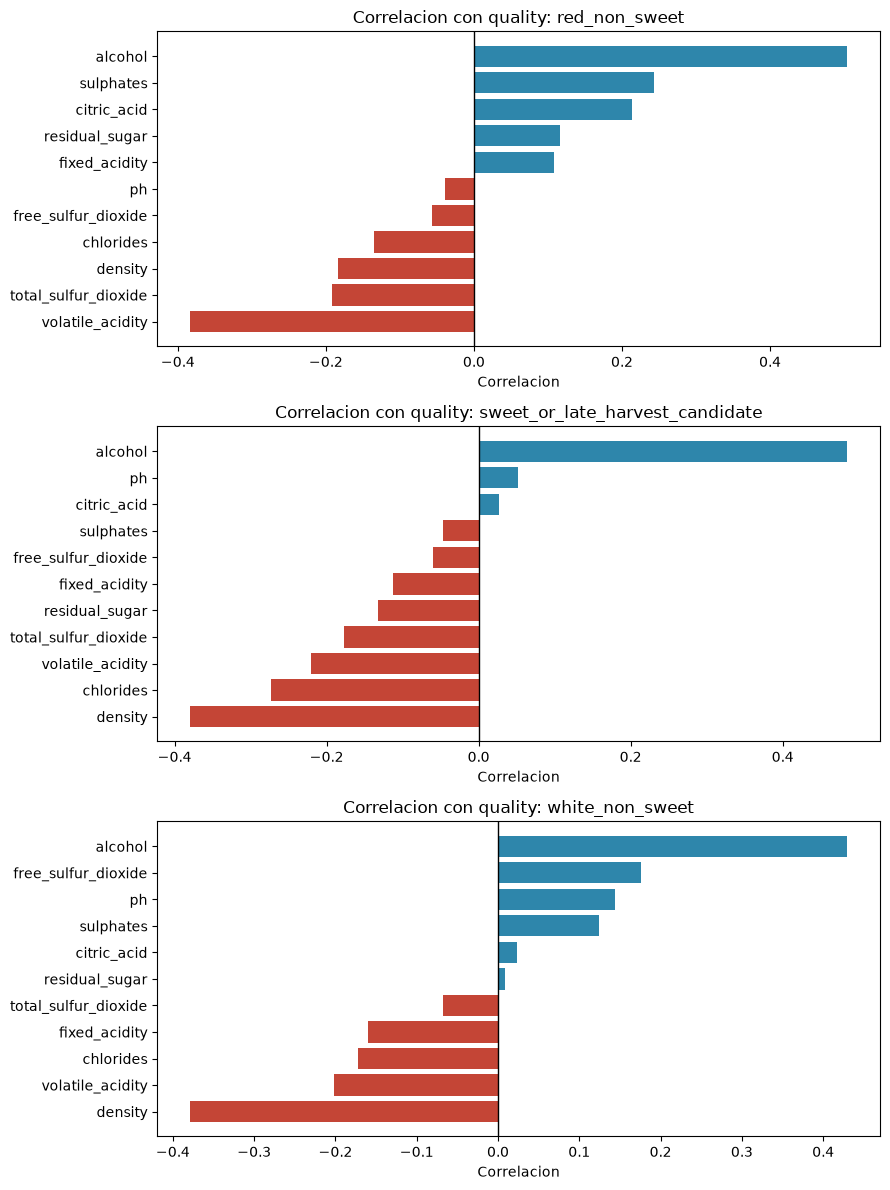

In [12]:
segments = correlations_by_segment["wine_segment"].unique()
fig, axes = plt.subplots(len(segments), 1, figsize=(9, 4 * len(segments)))

if len(segments) == 1:
    axes = [axes]

for ax, segment_name in zip(axes, segments):
    plot_data = (
        correlations_by_segment[correlations_by_segment["wine_segment"].eq(segment_name)]
        .sort_values("correlation_with_quality")
    )

    ax.barh(
        plot_data["feature"],
        plot_data["correlation_with_quality"],
        color=np.where(plot_data["correlation_with_quality"] > 0, "#2E86AB", "#C44536")
    )
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Correlacion con quality: {segment_name}")
    ax.set_xlabel("Correlacion")

plt.tight_layout()
plt.show()

### Grafico radial de correlaciones

El grafico radial reune las tres categorias en una sola imagen. Cada color representa un segmento de vino; cada eje representa una variable quimica.

La lectura es simple:

- El circulo central representa correlacion 0.
- Hacia afuera, la relacion con calidad es mas positiva.
- Hacia adentro, la relacion con calidad es mas negativa.
- Cuando las lineas de colores se separan mucho, esa variable diferencia categorias.

Este grafico no busca demostrar que un tipo de vino sea mejor que otro. Sirve para mostrar que la calidad se expresa con senales distintas segun el estilo.

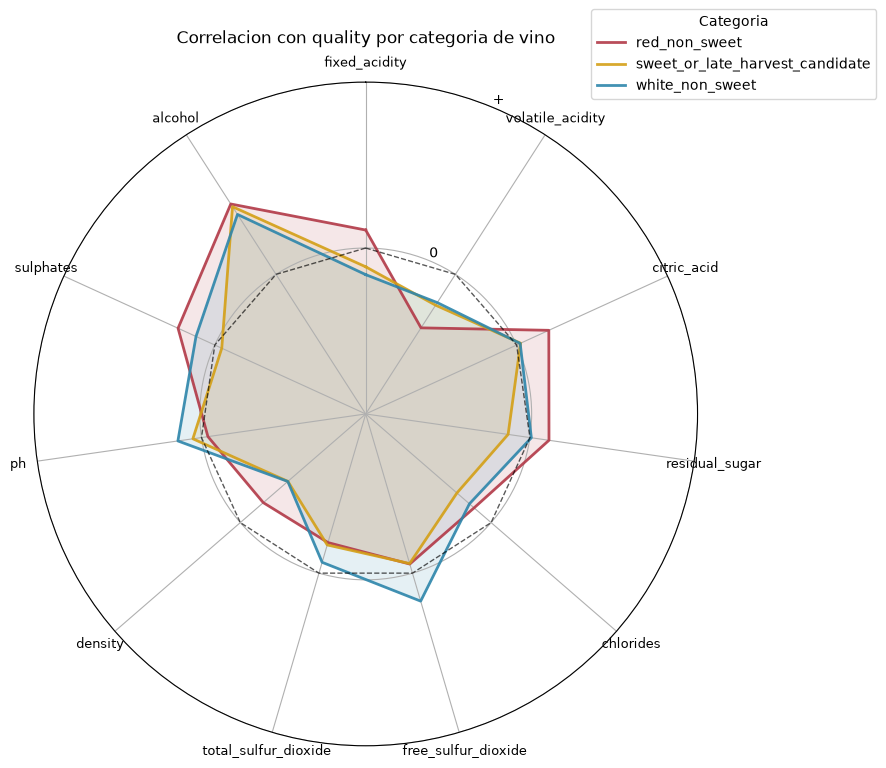

In [13]:
segment_colors = {
    "red_non_sweet": "#B23A48",
    "white_non_sweet": "#2E86AB",
    "sweet_or_late_harvest_candidate": "#D4A017",
}

def plot_radial_comparison(value_matrix, title, colors, normalize=False):
    """Grafico radial para comparar valores positivos y negativos por categoria."""
    plot_values = value_matrix.copy().astype(float)

    if normalize:
        max_abs = np.nanmax(np.abs(plot_values.values))
        if max_abs == 0:
            max_abs = 1
        plot_values = plot_values / max_abs

    plot_values = plot_values.clip(-1, 1)
    labels = plot_values.index.tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    for column in plot_values.columns:
        values = plot_values[column].fillna(0).values
        radii = 1 + values
        radii_closed = np.r_[radii, radii[0]]
        ax.plot(
            angles_closed,
            radii_closed,
            color=colors.get(column, "gray"),
            linewidth=2,
            alpha=0.9,
            label=column
        )
        ax.fill(
            angles_closed,
            radii_closed,
            color=colors.get(column, "gray"),
            alpha=0.12
        )

    ax.plot(angles_closed, np.ones_like(angles_closed), color="black", linewidth=1, linestyle="--", alpha=0.65)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 2)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["-", "0", "+"])
    ax.set_title(title, pad=28)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12), title="Categoria")
    plt.tight_layout()
    plt.show()


plot_corr = correlation_matrix_by_segment.reindex(model_features)
plot_radial_comparison(
    plot_corr,
    "Correlacion con quality por categoria de vino",
    segment_colors
)

## 6. Rangos de buen vino por categoria

Ademas de modelar, necesitamos traducir los resultados a rangos interpretables. Definimos un buen vino dentro de cada segmento como el 25% superior de `quality` de ese mismo grupo.

Esta decision evita comparar estilos de forma injusta. Un buen blanco dulce no tiene por que parecerse quimicamente a un buen tinto seco. Por eso calculamos rangos dentro de cada categoria y no con un unico umbral global.

La tabla resultante muestra percentiles, media y rango tipico. Para lectura de negocio, esto ayuda a describir perfiles: no solo que variable importa, sino en que rango suelen ubicarse los vinos mejor evaluados de cada grupo.

In [14]:
range_rows = []

for segment_name, segment_df in df.groupby("wine_segment"):
    quality_threshold = segment_df[target].quantile(0.75)
    good_wines = segment_df[segment_df[target] >= quality_threshold]

    for feature in model_features:
        range_rows.append({
            "wine_segment": segment_name,
            "feature": feature,
            "quality_threshold_p75": quality_threshold,
            "good_wine_p25": good_wines[feature].quantile(0.25),
            "good_wine_median": good_wines[feature].median(),
            "good_wine_p75": good_wines[feature].quantile(0.75),
            "good_wine_mean": good_wines[feature].mean(),
            "good_wine_count": len(good_wines)
        })

good_wine_ranges_by_segment = pd.DataFrame(range_rows)
good_wine_ranges_by_segment["typical_range"] = (
    good_wine_ranges_by_segment["good_wine_p25"].round(2).astype(str)
    + " to "
    + good_wine_ranges_by_segment["good_wine_p75"].round(2).astype(str)
)

good_wine_ranges_by_segment = good_wine_ranges_by_segment.merge(
    correlations_by_segment[["wine_segment", "feature", "correlation_with_quality"]],
    on=["wine_segment", "feature"],
    how="left"
).merge(
    feature_importance_by_segment,
    on=["wine_segment", "feature"],
    how="left"
)

good_wine_ranges_by_segment.sort_values(
    ["wine_segment", "importance"],
    ascending=[True, False]
).round(4)

,wine_segment,feature,quality_threshold_p75,good_wine_p25,good_wine_median,good_wine_p75,good_wine_mean,good_wine_count,typical_range,correlation_with_quality,importance
10,red_non_sweet,alcohol,0.2323,-0.4632,0.2115,0.9704,0.2894,686,-0.46 to 0.97,0.5041,0.2917
9,red_non_sweet,sulphates,0.2323,0.3783,0.9126,1.6473,1.0858,686,0.38 to 1.65,0.2433,0.1325
1,red_non_sweet,volatile_acidity,0.2323,-0.0245,0.5699,1.4020,0.7337,686,-0.02 to 1.4,-0.3833,0.1298
6,red_non_sweet,total_sulfur_dioxide,0.2323,-1.6578,-1.4552,-1.1469,-1.3312,686,-1.66 to -1.15,-0.1921,0.0682
8,red_non_sweet,ph,0.2323,-0.0914,0.4698,1.0934,0.5074,686,-0.09 to 1.09,-0.0393,0.0609
4,red_non_sweet,chlorides,0.2323,0.2526,0.5374,0.8223,0.7047,686,0.25 to 0.82,-0.1356,0.0577
3,red_non_sweet,residual_sugar,0.2323,-0.6997,-0.6330,-0.5664,-0.5974,686,-0.7 to -0.57,0.1159,0.0554
7,red_non_sweet,density,0.2323,0.1989,0.6221,1.0335,0.6264,686,0.2 to 1.03,-0.1835,0.0535
0,red_non_sweet,fixed_acidity,0.2323,-0.0115,0.7463,1.9589,0.9968,686,-0.01 to 1.96,0.1084,0.0516
2,red_non_sweet,citric_acid,0.2323,-1.3320,0.0782,1.0127,-0.0578,686,-1.33 to 1.01,0.2132,0.0508


In [15]:
difference_rows = []

for segment_name, segment_df in df.groupby("wine_segment"):
    quality_threshold = segment_df[target].quantile(0.75)
    good_wines = segment_df[segment_df[target] >= quality_threshold]
    rest_of_wines = segment_df[segment_df[target] < quality_threshold]

    for feature in model_features:
        difference_rows.append({
            "wine_segment": segment_name,
            "feature": feature,
            "good_wine_mean": good_wines[feature].mean(),
            "rest_mean": rest_of_wines[feature].mean(),
            "difference_good_minus_rest": good_wines[feature].mean() - rest_of_wines[feature].mean()
        })

good_vs_rest_by_segment = pd.DataFrame(difference_rows).merge(
    correlations_by_segment[["wine_segment", "feature", "correlation_with_quality"]],
    on=["wine_segment", "feature"],
    how="left"
).merge(
    feature_importance_by_segment,
    on=["wine_segment", "feature"],
    how="left"
)

good_vs_rest_by_segment.sort_values(
    ["wine_segment", "difference_good_minus_rest"],
    key=lambda values: values.abs() if values.name == "difference_good_minus_rest" else values,
    ascending=[True, False]
).round(4)

,wine_segment,feature,good_wine_mean,rest_mean,difference_good_minus_rest,correlation_with_quality,importance
10,red_non_sweet,alcohol,0.2894,-0.5426,0.8319,0.5041,0.2917
1,red_non_sweet,volatile_acidity,0.7337,1.4283,-0.6946,-0.3833,0.1298
9,red_non_sweet,sulphates,1.0858,0.6020,0.4838,0.2433,0.1325
2,red_non_sweet,citric_acid,-0.0578,-0.4733,0.4155,0.2132,0.0508
4,red_non_sweet,chlorides,0.7047,1.0219,-0.3172,-0.1356,0.0577
6,red_non_sweet,total_sulfur_dioxide,-1.3312,-1.0413,-0.2899,-0.1921,0.0682
0,red_non_sweet,fixed_acidity,0.9968,0.7643,0.2325,0.1084,0.0516
7,red_non_sweet,density,0.6264,0.8316,-0.2052,-0.1835,0.0535
5,red_non_sweet,free_sulfur_dioxide,-0.8490,-0.7677,-0.0813,-0.0571,0.0479
8,red_non_sweet,ph,0.5074,0.4881,0.0193,-0.0393,0.0609


## 7. Regresion logistica: bueno vs malo

Hasta aqui analizamos `quality` como valor continuo. Ahora reformulamos la pregunta como clasificacion: **puede la quimica ayudarnos a distinguir vinos buenos de vinos no buenos?**

Definimos como buen vino a los registros con `quality` en el percentil 70 o superior. En palabras simples, no estamos considerando aquellos vinos que superen "8/10" sino que estamos considerando unicamente aquellos que se encuentran entre el 30% de mejor calidad de la muestra.

La regresion logistica entrega dos cosas utiles:

- Metricas de clasificacion: accuracy, precision, recall, F1 y ROC AUC.
- Coeficientes: indican que variables empujan la probabilidad hacia buen vino o hacia no buen vino.

Aun asi, hay que tener cuidado: un modelo global bueno/malo puede ser util como referencia, pero no como explicacion final. Ya demostramos que los factores no se comportan igual por categoria.

In [16]:
def evaluate_classification_model(model_name, model, X_train, X_test, y_train, y_test):
    """Entrena un clasificador binario y devuelve metricas principales."""
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_proba),
    }


def plot_confusion_matrix_simple(y_true, y_pred, title, labels=("Malo", "Bueno")):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [17]:
global_good_threshold = df[target].quantile(0.70)
df["good_wine_70p_global"] = (df[target] >= global_good_threshold).astype(int)

X = df[model_features]
y = df["good_wine_70p_global"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

logistic_good_global = LogisticRegression(max_iter=1000, class_weight="balanced")
good_global_results = evaluate_classification_model(
    "Logistic Regression - good wine global",
    logistic_good_global,
    X_train,
    X_test,
    y_train,
    y_test
)

good_global_results = pd.DataFrame([good_global_results]).round(4)
good_global_results

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - good wine global,0.7434,0.8259,0.7477,0.7849,0.8145


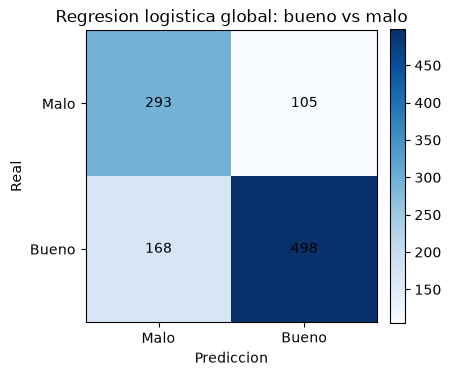

In [18]:
global_good_pred = logistic_good_global.predict(X_test)
plot_confusion_matrix_simple(
    y_test,
    global_good_pred,
    "Regresion logistica global: bueno vs malo"
)

### Por que no interpretamos los coeficientes globales como verdad final

El modelo global bueno/malo queda como referencia de desempeno general. Sin embargo, no usaremos sus coeficientes para declarar que ciertos factores hacen bueno a cualquier vino.

Esa seria una conclusion sesgada: un vino blanco no dulce, un tinto y un candidato dulce pueden tener rutas quimicas distintas hacia una buena evaluacion. Por eso la lectura realmente valiosa aparece cuando repetimos la regresion logistica dentro de cada categoria.

### Regresion logistica bueno/malo por categoria

Aqui esta una de las piezas mas importantes del proyecto. Repetimos la clasificacion bueno/malo dentro de cada segmento, con un umbral propio de percentil 70 para cada categoria.

Esto evita comparar un buen blanco no dulce contra un buen tinto como si ambos debieran expresar la calidad de la misma forma. En cambio, preguntamos: **dentro de cada estilo, que factores aumentan o reducen la probabilidad de estar entre los mejores?**

El grafico radial de coeficientes no debe leerse solo como un ranking de calidad. Tambien revela diferencias estructurales entre categorias. En la lectura actual del proyecto se observan picos especialmente informativos:

- En blancos no dulces, `density` aparece con un pico negativo mas marcado que en tintos y candidatos dulces, donde se mantiene mas cerca de cero.
- `residual_sugar` separa al blanco no dulce de los otros grupos, mostrando que el azucar no cumple el mismo papel en todos los estilos.
- En el mismo grafico, el blanco no dulce tambien se aleja en `alcohol`, reforzando que su perfil de calidad no replica el de los otros segmentos.
- En tintos, `total_sulfur_dioxide` se desplaza hacia una zona mas negativa que en los vinos blancos, lo que sugiere una lectura distinta de esa variable dentro del segmento tinto.

Esta visualizacion es poderosa porque muestra algo mas profundo que bueno/malo: muestra que las categorias de vino tienen reglas internas diferentes.

In [19]:
segmented_good_results = []
segmented_good_coefficients = []
segmented_good_models = {}

for segment_name, segment_df in df.groupby("wine_segment"):
    segment_threshold = segment_df[target].quantile(0.70)
    segment_y = (segment_df[target] >= segment_threshold).astype(int)
    positive_count = int(segment_y.sum())

    if segment_y.nunique() < 2 or len(segment_df) < 80:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        segment_df[model_features],
        segment_y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=segment_y
    )

    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    results = evaluate_classification_model(
        "Logistic Regression - good wine by segment",
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    results["wine_segment"] = segment_name
    results["rows"] = len(segment_df)
    results["quality_threshold_p70"] = segment_threshold
    results["positive_cases"] = positive_count
    results["positive_rate"] = positive_count / len(segment_df)
    segmented_good_results.append(results)
    segmented_good_models[segment_name] = model

    segmented_good_coefficients.append(pd.DataFrame({
        "wine_segment": segment_name,
        "feature": model_features,
        "coefficient": model.coef_[0]
    }))

segmented_good_results = pd.DataFrame(segmented_good_results).round(4)
segmented_good_coefficients = pd.concat(segmented_good_coefficients, ignore_index=True)

segmented_good_results[["wine_segment", "rows", "positive_cases", "positive_rate", "quality_threshold_p70", "accuracy", "precision", "recall", "f1", "roc_auc"]]

,wine_segment,rows,positive_cases,positive_rate,quality_threshold_p70,accuracy,precision,recall,f1,roc_auc
0,red_non_sweet,1269,686,0.5406,0.2323,0.7717,0.7842,0.7956,0.7899,0.8501
1,sweet_or_late_harvest_candidate,2139,1316,0.6152,0.2323,0.7126,0.8271,0.6730,0.7421,0.7954
2,white_non_sweet,1912,1330,0.6956,0.2323,0.7781,0.8577,0.8158,0.8362,0.8391


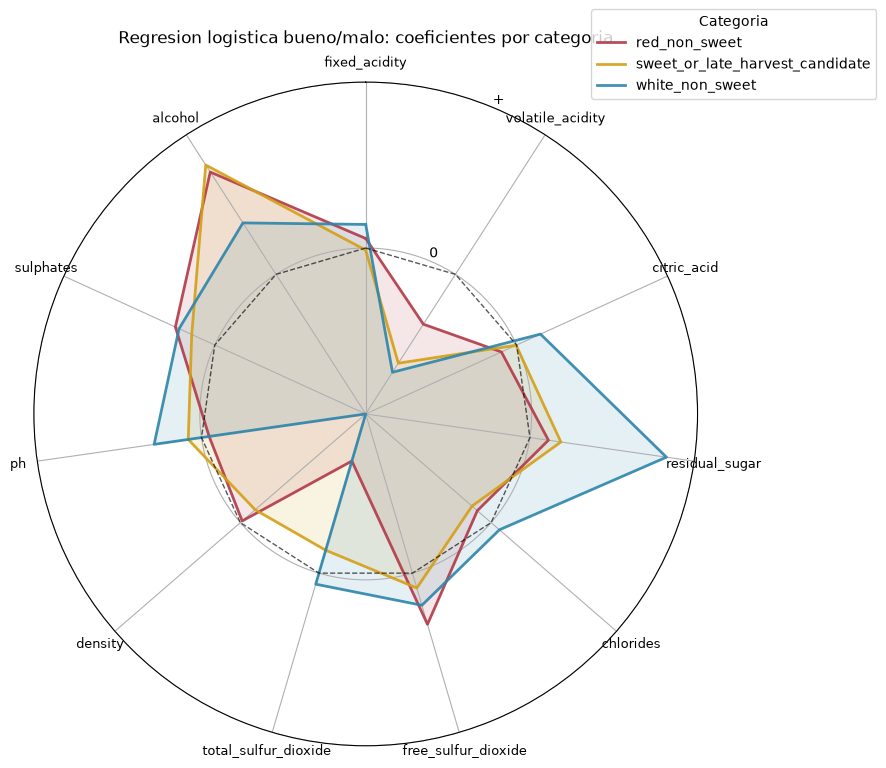

wine_segment,red_non_sweet,sweet_or_late_harvest_candidate,white_non_sweet
feature,,,
fixed_acidity,0.0811,-0.0175,0.2002
volatile_acidity,-0.5032,-0.8966,-0.9883
citric_acid,-0.1420,-0.0051,0.2228
residual_sugar,0.1585,0.2652,1.1711
chlorides,-0.1547,-0.2141,0.0933
free_sulfur_dioxide,0.4529,0.1314,0.2844
total_sulfur_dioxide,-0.9921,-0.2029,0.0976
density,-0.0211,-0.1666,-1.4089
ph,-0.0658,0.1135,0.4063


In [20]:
coef_matrix = segmented_good_coefficients.pivot(
    index="feature",
    columns="wine_segment",
    values="coefficient"
).reindex(model_features)

plot_radial_comparison(
    coef_matrix,
    "Regresion logistica bueno/malo: coeficientes por categoria",
    segment_colors,
    normalize=True
)

coef_matrix.round(4)

### Interpretacion del radial bueno/malo por categoria

En este grafico, cada eje es una variable y cada color es una categoria. Como los coeficientes se normalizan para visualizacion, el objetivo principal es comparar formas y picos, no leer magnitudes absolutas.

Cuando una categoria se aleja de las otras en una variable, esa diferencia sugiere que el factor tiene un papel mas especifico en ese tipo de vino. Por eso este grafico funciona como puente entre modelado e interpretacion de mercado: ayuda a detectar donde un vino blanco, tinto o dulce candidato tiene una logica de calidad distinta.

La informacion de calidad completa no vive solo aqui. Este radial debe leerse junto con los rangos de buen vino, las correlaciones por categoria, las importancias del Random Forest y los clusters de calidad relativa.

## 8. Regresion logistica para distinguir tintos y blancos

Este modelo responde otra pregunta: **la quimica del dataset distingue vinos tintos y blancos?**

Aqui no usamos `wine_segment`, porque esa variable fue creada por nosotros. Usamos la etiqueta real `type`:

- `1`: vino tinto.
- `0`: vino blanco.

Este bloque no mide calidad. Su valor esta en validar que las variables quimicas contienen senales suficientes para separar tipos principales de vino. Si el modelo distingue bien tintos y blancos, refuerza la tesis del notebook: mezclar categorias antes de analizar calidad puede introducir sesgo.

In [21]:
type_df = df[df["type"].isin(["red", "white"])].copy()
type_df["is_red"] = type_df["type"].eq("red").astype(int)

X = type_df[model_features]
y = type_df["is_red"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

logistic_red_white = LogisticRegression(max_iter=1000, class_weight="balanced")
red_white_results = evaluate_classification_model(
    "Logistic Regression - red vs white",
    logistic_red_white,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([red_white_results]).round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - red vs white,0.9906,0.9746,0.989,0.9818,0.996


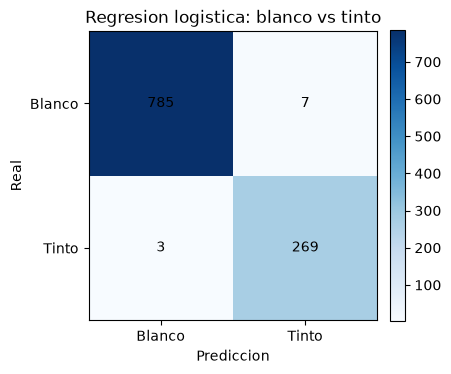

In [22]:
red_white_pred = logistic_red_white.predict(X_test)
plot_confusion_matrix_simple(
    y_test,
    red_white_pred,
    "Regresion logistica: blanco vs tinto",
    labels=("Blanco", "Tinto")
)

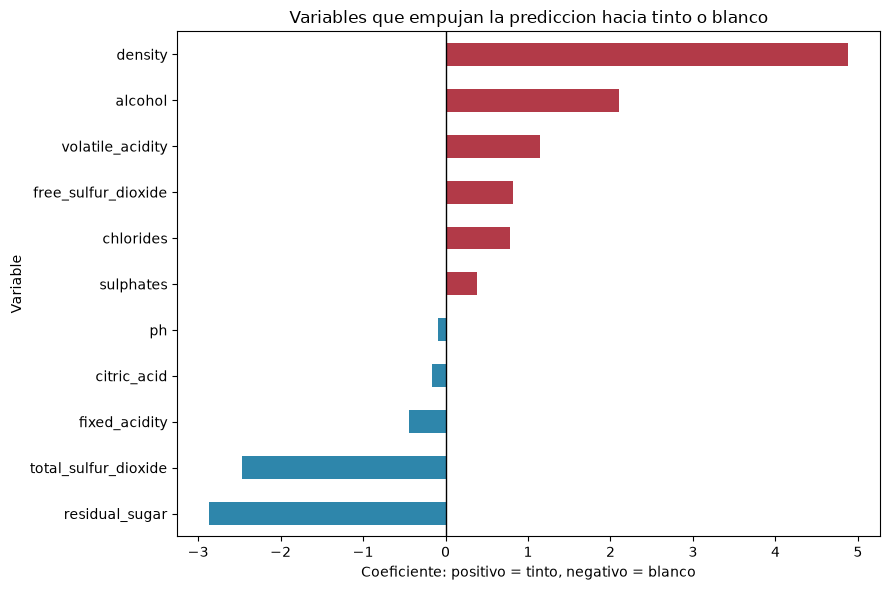

,feature,coefficient_toward_red
3,residual_sugar,-2.8659
6,total_sulfur_dioxide,-2.4702
0,fixed_acidity,-0.4477
2,citric_acid,-0.1693
8,ph,-0.0932
9,sulphates,0.3864
4,chlorides,0.7850
5,free_sulfur_dioxide,0.8207
1,volatile_acidity,1.1437
10,alcohol,2.1075


In [23]:
red_white_coefficients = pd.DataFrame({
    "feature": model_features,
    "coefficient_toward_red": logistic_red_white.coef_[0]
}).sort_values("coefficient_toward_red")

ax = red_white_coefficients.plot(
    x="feature",
    y="coefficient_toward_red",
    kind="barh",
    figsize=(9, 6),
    legend=False,
    color=np.where(red_white_coefficients["coefficient_toward_red"] > 0, "#B23A48", "#2E86AB")
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Variables que empujan la prediccion hacia tinto o blanco")
ax.set_xlabel("Coeficiente: positivo = tinto, negativo = blanco")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

red_white_coefficients.round(4)

### Que aporta este modelo al proyecto

Si las variables quimicas separan bien tintos y blancos, entonces el dataset no es un bloque homogeneo. Esto importa porque un modelo de calidad global puede estar mezclando efectos de tipo de vino con efectos reales de calidad.

Para una audiencia no tecnica, la lectura es directa: antes de decidir que hace bueno a un vino, necesitamos saber de que familia de vino estamos hablando.

## 9. Clustering: convertir miles de vinos en perfiles interpretables

El clustering resume todos los vinos en grupos quimicos. A diferencia de los modelos anteriores, aqui el algoritmo no recibe `quality`, `type` ni `wine_segment` para crear los grupos. Solo observa las variables quimicas.

Esto nos permite responder una pregunta de negocio: **existen familias quimicas naturales dentro del dataset, y esas familias se relacionan con estilo o calidad?**

Usamos `KMeans` con 6 clusters para obtener perfiles mas finos que los tres segmentos iniciales. Despues interpretamos esos clusters con variables que el algoritmo no uso directamente: calidad media, proporcion de tintos, proporcion de blancos, candidatos dulces y porcentaje de vinos buenos.

Para graficar usamos PCA. PCA significa *Principal Component Analysis*. Es una tecnica que comprime muchas variables en dos ejes visuales, `PCA 1` y `PCA 2`. Estos ejes no son variables originales como alcohol o acidez; son combinaciones matematicas que capturan la mayor parte posible de la variacion quimica. En simple: PCA crea un mapa 2D donde vinos quimicamente parecidos tienden a quedar cerca.

In [24]:
cluster_features = model_features.copy()

N_CLUSTERS = 6

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
df["cluster"] = kmeans.fit_predict(df[cluster_features])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(df[cluster_features])
df["pca_1"] = pca_coordinates[:, 0]
df["pca_2"] = pca_coordinates[:, 1]

print(f"Varianza explicada por PCA 1 y PCA 2: {pca.explained_variance_ratio_.sum():.2%}")
pd.Series(df["cluster"]).value_counts().sort_index()

C:\Users\kinga\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kinga\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kinga\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\kinga\AppData\Local\Programs\Python\Python312\Lib\subpr

Varianza explicada por PCA 1 y PCA 2: 49.67%


cluster
0    1146
1    1378
2      32
3     573
4     801
5    1390
Name: count, dtype: int64

### Mapa quimico de clusters

El siguiente grafico muestra los 6 clusters en el mapa PCA. Cada punto es un vino; cada color es un cluster quimico.

Por si solo, un color no tiene significado comercial. El cluster rosa, azul o verde no es importante por su color, sino por **donde aparece** y por **que perfil contiene**. Si un cluster queda separado, significa que esos vinos tienen una composicion quimica distinta. Si queda cerca de otro, significa que sus perfiles se parecen mas.

La pregunta de lectura no es `que color se ve bonito?`, sino: **que vinos viven en esa zona del mapa, y que sabemos de su calidad, dulzor o tipo?** Las tablas posteriores traducen cada cluster a lenguaje de negocio.

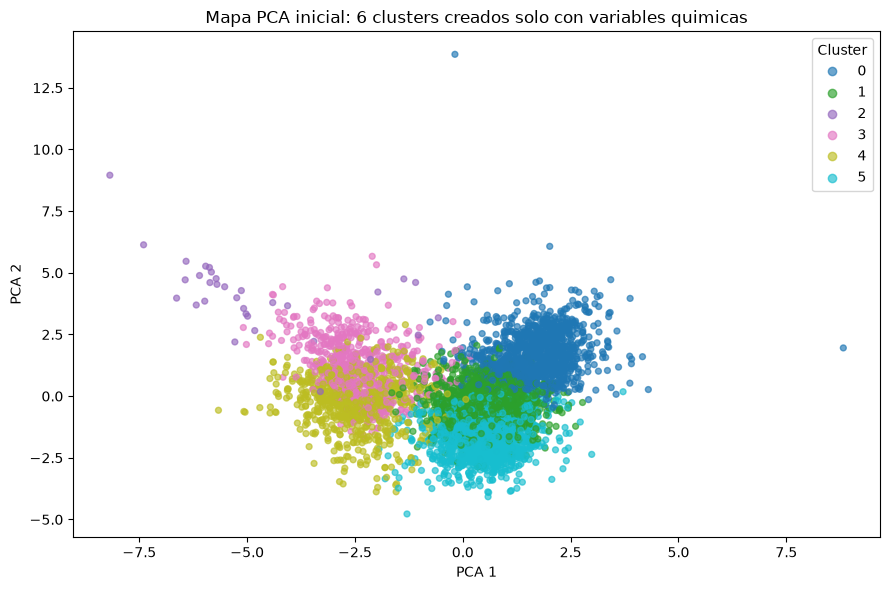

In [25]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df["pca_1"],
    df["pca_2"],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.65,
    s=18
)
plt.title("Mapa PCA inicial: 6 clusters creados solo con variables quimicas")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

### Segmentos sobre el mapa de clusters

Ahora usamos el mismo mapa PCA, pero coloreamos por nuestras categorias analiticas: tintos no dulces, blancos no dulces y candidatos dulces o late harvest.

Esta visualizacion conecta el modelado con una lectura intuitiva. Si los blancos no dulces aparecen agrupados en una zona, significa que comparten un perfil quimico reconocible. Si los tintos aparecen en otra zona, significa que el algoritmo tambien ve una diferencia estructural entre familias de vino. Si los candidatos dulces se desplazan hacia un area propia, refuerza la decision de analizarlos aparte.

Para inversion o seleccion de producto, esto importa porque permite ubicar estilos en un mapa de similitud quimica antes de hablar de calidad.

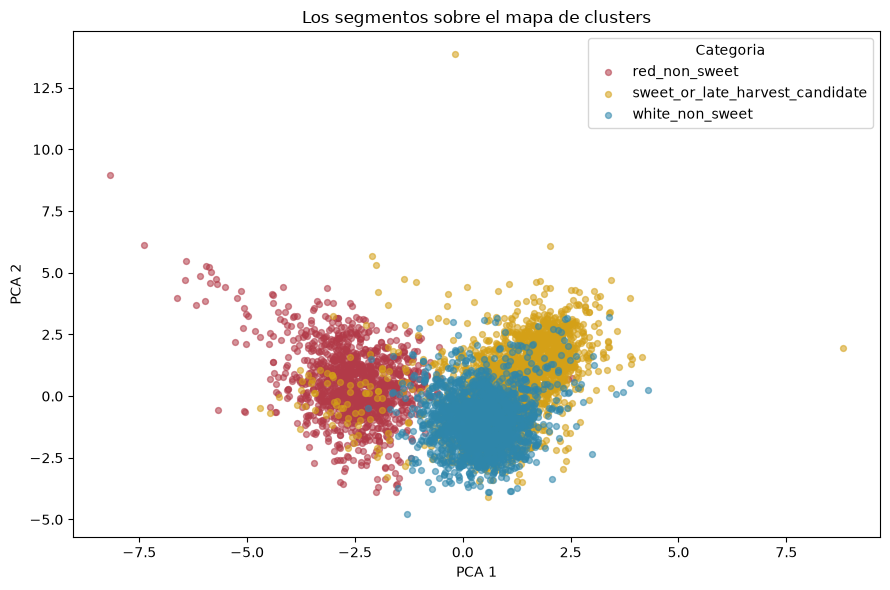

In [26]:
plt.figure(figsize=(9, 6))

for segment_name, segment_df in df.groupby("wine_segment"):
    plt.scatter(
        segment_df["pca_1"],
        segment_df["pca_2"],
        label=segment_name,
        color=segment_colors.get(segment_name, "gray"),
        alpha=0.55,
        s=18
    )

plt.title("Los segmentos sobre el mapa de clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Categoria")
plt.tight_layout()
plt.show()

### Traducir clusters a informacion accionable

El mapa visual necesita una tabla que explique que significa cada grupo. Por eso calculamos un perfil para cada cluster: cantidad de vinos, calidad media, azucar residual medio, acidez media, proporcion de tintos, proporcion de blancos, proporcion de candidatos dulces y porcentaje de vinos sobre el percentil 70 de calidad.

Esta tabla es la que vuelve util al grafico. Sin ella, `cluster 0` o `cluster 3` son solo etiquetas tecnicas. Con ella podemos decir, por ejemplo, si un cluster representa mayormente blancos, si concentra candidatos dulces o si aparece asociado a calidad relativa mas alta.

In [27]:
cluster_profile = df.groupby("cluster").agg(
    rows=("quality", "size"),
    mean_quality=("quality", "mean"),
    median_quality=("quality", "median"),
    mean_residual_sugar=("residual_sugar", "mean"),
    mean_acidity_index=("acidity_index", "mean"),
    mean_sweetness_acidity_score=("sweetness_acidity_score", "mean"),
    pct_red=("type", lambda values: values.eq("red").mean()),
    pct_white=("type", lambda values: values.eq("white").mean()),
    pct_sweet_candidate=("sweet_candidate", "mean"),
    pct_good_global_70p=("good_wine_70p_global", "mean")
).round(4)

cluster_profile

,rows,mean_quality,median_quality,mean_residual_sugar,mean_acidity_index,mean_sweetness_acidity_score,pct_red,pct_white,pct_sweet_candidate,pct_good_global_70p
cluster,,,,,,,,,,
0,1146,-0.2657,0.2323,1.4996,0.0802,1.4194,0.0035,0.9965,0.9476,0.5175
1,1378,-0.0556,0.2323,-0.3149,-0.2001,-0.1149,0.0189,0.9811,0.3795,0.6168
2,32,-0.6558,-0.9045,-0.3955,0.9610,-1.3565,0.8125,0.1875,0.1562,0.3125
3,573,0.0498,0.2323,-0.5136,1.4172,-1.9308,0.9337,0.0663,0.0140,0.6405
4,801,-0.4787,-0.9045,-0.5734,-0.6197,0.0463,0.9326,0.0674,0.1273,0.4170
5,1390,0.5447,0.2323,-0.3729,-0.1170,-0.2559,0.0151,0.9849,0.2986,0.8475


In [28]:
quality_low_cut = cluster_profile["mean_quality"].quantile(0.33)
quality_high_cut = cluster_profile["mean_quality"].quantile(0.66)


def quality_cluster_label(mean_quality):
    if mean_quality >= quality_high_cut:
        return "alta calidad relativa"
    if mean_quality <= quality_low_cut:
        return "baja calidad relativa"
    return "calidad media"


def dominant_style_label(row):
    if row["pct_sweet_candidate"] >= 0.55:
        return "dulce / late harvest candidato"
    if row["pct_red"] >= 0.70:
        return "mayoria tinto"
    if row["pct_white"] >= 0.70:
        return "mayoria blanco"
    return "mixto"


def chemical_profile_label(row):
    if row["mean_sweetness_acidity_score"] >= 0.50:
        return "dulzor alto frente a acidez"
    if row["mean_acidity_index"] >= 0.50 and row["mean_residual_sugar"] <= 0:
        return "acidez marcada y bajo azucar"
    if row["mean_residual_sugar"] <= -0.25:
        return "seco / bajo azucar"
    return "balance intermedio"


cluster_interpretation = cluster_profile.copy()
cluster_interpretation["quality_profile"] = cluster_interpretation["mean_quality"].apply(quality_cluster_label)
cluster_interpretation["dominant_style"] = cluster_interpretation.apply(dominant_style_label, axis=1)
cluster_interpretation["chemical_profile"] = cluster_interpretation.apply(chemical_profile_label, axis=1)

df["cluster_quality_profile"] = df["cluster"].map(cluster_interpretation["quality_profile"])
df["cluster_dominant_style"] = df["cluster"].map(cluster_interpretation["dominant_style"])

cluster_interpretation[[
    "rows",
    "quality_profile",
    "dominant_style",
    "chemical_profile",
    "mean_quality",
    "pct_good_global_70p",
    "pct_red",
    "pct_white",
    "pct_sweet_candidate",
    "mean_residual_sugar",
    "mean_acidity_index",
    "mean_sweetness_acidity_score"
]]

,rows,quality_profile,dominant_style,chemical_profile,mean_quality,pct_good_global_70p,pct_red,pct_white,pct_sweet_candidate,mean_residual_sugar,mean_acidity_index,mean_sweetness_acidity_score
cluster,,,,,,,,,,,,
0,1146,calidad media,dulce / late harvest candidato,dulzor alto frente a acidez,-0.2657,0.5175,0.0035,0.9965,0.9476,1.4996,0.0802,1.4194
1,1378,calidad media,mayoria blanco,seco / bajo azucar,-0.0556,0.6168,0.0189,0.9811,0.3795,-0.3149,-0.2001,-0.1149
2,32,baja calidad relativa,mayoria tinto,acidez marcada y bajo azucar,-0.6558,0.3125,0.8125,0.1875,0.1562,-0.3955,0.9610,-1.3565
3,573,alta calidad relativa,mayoria tinto,acidez marcada y bajo azucar,0.0498,0.6405,0.9337,0.0663,0.0140,-0.5136,1.4172,-1.9308
4,801,baja calidad relativa,mayoria tinto,seco / bajo azucar,-0.4787,0.4170,0.9326,0.0674,0.1273,-0.5734,-0.6197,0.0463
5,1390,alta calidad relativa,mayoria blanco,seco / bajo azucar,0.5447,0.8475,0.0151,0.9849,0.2986,-0.3729,-0.1170,-0.2559


### Explicacion automatica de cada cluster

La siguiente celda genera una lectura en lenguaje natural para cada cluster. Esto ayuda a que el notebook sea legible fuera de un contexto tecnico: no obliga al lector a interpretar solo numeros, sino que traduce cada grupo en estilo dominante, perfil quimico y calidad relativa.

Esta traduccion es especialmente importante para perfiles de inversion: el interes no esta en saber que existe un `cluster 2`, sino en entender si ese cluster concentra blancos, tintos, dulces candidatos, vinos de mayor calidad relativa o perfiles quimicos extremos.

In [29]:
for cluster_id, row in cluster_interpretation.iterrows():
    print(f"Cluster {cluster_id}")
    print(f"- Tamano: {int(row['rows'])} vinos")
    print(f"- Perfil de calidad: {row['quality_profile']}")
    print(f"- Estilo dominante: {row['dominant_style']}")
    print(f"- Perfil quimico: {row['chemical_profile']}")
    print(f"- Vinos buenos globales, percentil 70+: {row['pct_good_global_70p']:.1%}")
    print(f"- Composicion: {row['pct_red']:.1%} tintos, {row['pct_white']:.1%} blancos, {row['pct_sweet_candidate']:.1%} dulces candidatos")
    print()

Cluster 0
- Tamano: 1146 vinos
- Perfil de calidad: calidad media
- Estilo dominante: dulce / late harvest candidato
- Perfil quimico: dulzor alto frente a acidez
- Vinos buenos globales, percentil 70+: 51.7%
- Composicion: 0.4% tintos, 99.7% blancos, 94.8% dulces candidatos

Cluster 1
- Tamano: 1378 vinos
- Perfil de calidad: calidad media
- Estilo dominante: mayoria blanco
- Perfil quimico: seco / bajo azucar
- Vinos buenos globales, percentil 70+: 61.7%
- Composicion: 1.9% tintos, 98.1% blancos, 38.0% dulces candidatos

Cluster 2
- Tamano: 32 vinos
- Perfil de calidad: baja calidad relativa
- Estilo dominante: mayoria tinto
- Perfil quimico: acidez marcada y bajo azucar
- Vinos buenos globales, percentil 70+: 31.2%
- Composicion: 81.2% tintos, 18.8% blancos, 15.6% dulces candidatos

Cluster 3
- Tamano: 573 vinos
- Perfil de calidad: alta calidad relativa
- Estilo dominante: mayoria tinto
- Perfil quimico: acidez marcada y bajo azucar
- Vinos buenos globales, percentil 70+: 64.0%
- C

### Mapa de clusters anotado

El primer mapa de clusters muestra la estructura visual. El siguiente la traduce: ubicamos el centro de cada cluster y lo anotamos con su numero, perfil de calidad y estilo dominante.

Esto responde preguntas practicas: que significa que exista un cluster en esa zona, si concentra tintos o blancos, y si su perfil se asocia a calidad relativa alta, media o baja.

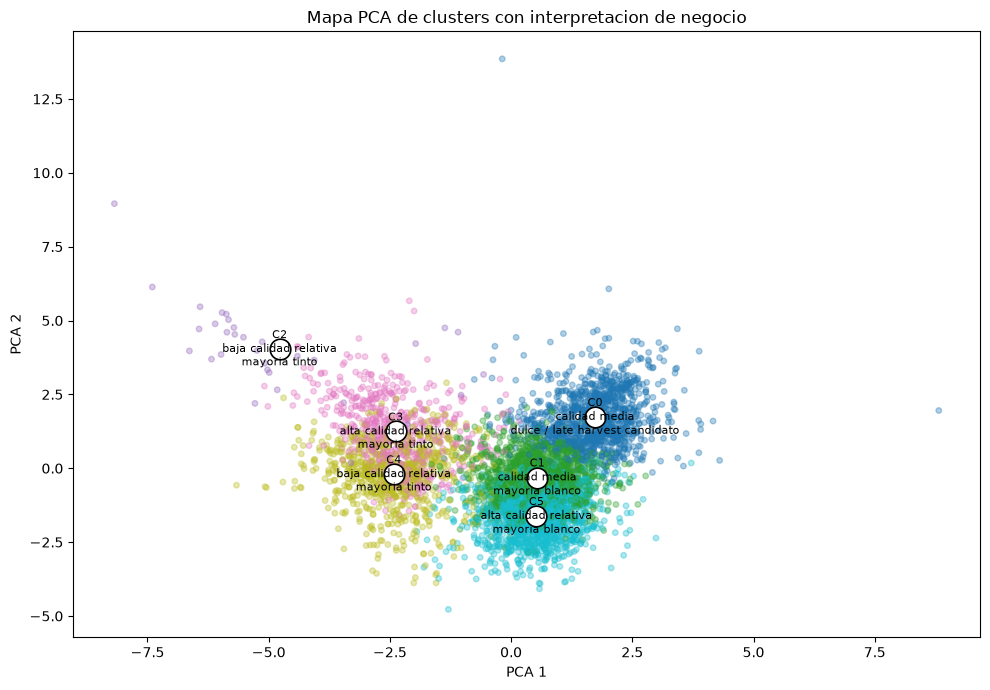

In [30]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df["pca_1"],
    df["pca_2"],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.35,
    s=16
)

cluster_centroids = df.groupby("cluster")[["pca_1", "pca_2"]].mean()

for cluster_id, centroid in cluster_centroids.iterrows():
    row = cluster_interpretation.loc[cluster_id]
    label = (
        f"C{cluster_id}\n"
        f"{row['quality_profile']}\n"
        f"{row['dominant_style']}"
    )
    plt.scatter(
        centroid["pca_1"],
        centroid["pca_2"],
        s=220,
        color="white",
        edgecolor="black",
        linewidth=1.2
    )
    plt.text(
        centroid["pca_1"],
        centroid["pca_2"],
        label,
        ha="center",
        va="center",
        fontsize=8
    )

plt.title("Mapa PCA de clusters con interpretacion de negocio")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

### Clusters agrupados por calidad relativa

El siguiente mapa usa el mismo espacio PCA, pero cambia la pregunta visual. En vez de colorear por numero de cluster o por segmento de vino, colorea por perfil relativo de calidad: alta, media o baja.

Esto nos permite ubicar zonas del mapa quimico donde aparecen vinos con mejor desempeno relativo. Para un lector no tecnico, la lectura es: **en que region del mapa viven los vinos que tienden a tener mejor calidad?**

La respuesta no reemplaza el analisis por categoria, pero lo complementa. Si una zona de alta calidad se superpone con blancos no dulces, tintos o candidatos dulces, eso abre una lectura comercial mas concreta.

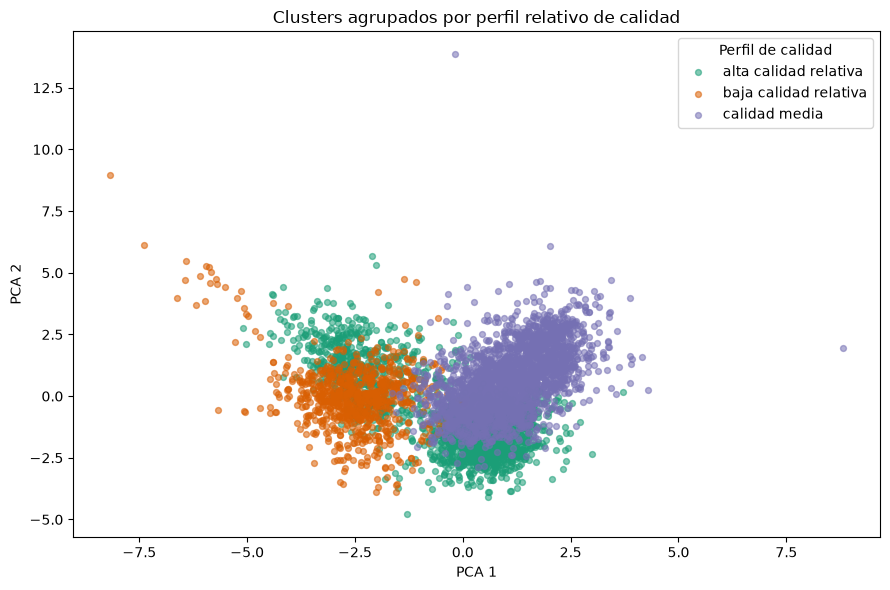

In [31]:
quality_profile_colors = {
    "alta calidad relativa": "#1B9E77",
    "calidad media": "#7570B3",
    "baja calidad relativa": "#D95F02",
}

plt.figure(figsize=(9, 6))

for quality_profile, profile_df in df.groupby("cluster_quality_profile"):
    plt.scatter(
        profile_df["pca_1"],
        profile_df["pca_2"],
        label=quality_profile,
        color=quality_profile_colors.get(quality_profile, "gray"),
        alpha=0.55,
        s=18
    )

plt.title("Clusters agrupados por perfil relativo de calidad")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Perfil de calidad")
plt.tight_layout()
plt.show()

### Mapa combinado: segmento, calidad relativa y trayectoria

Esta es la visualizacion mas importante del bloque de clustering. Superpone dos lecturas que antes estaban separadas:

- El color de fondo muestra zonas de calidad relativa: alta, media y baja.
- Las lineas y marcadores muestran donde cae cada segmento de vino dentro de esas zonas.

La linea de cada segmento conecta sus centroides desde baja calidad relativa hacia alta calidad relativa, cuando esas zonas existen para ese segmento. En terminos simples: muestra hacia donde se desplaza cada categoria cuando pasa de perfiles menos favorables a perfiles mas favorables dentro del mapa quimico.

Esto permite responder una pregunta mas valiosa que `que cluster es cual?`: **que zona del espacio quimico concentra mejores vinos, y que categorias llegan a esa zona?**

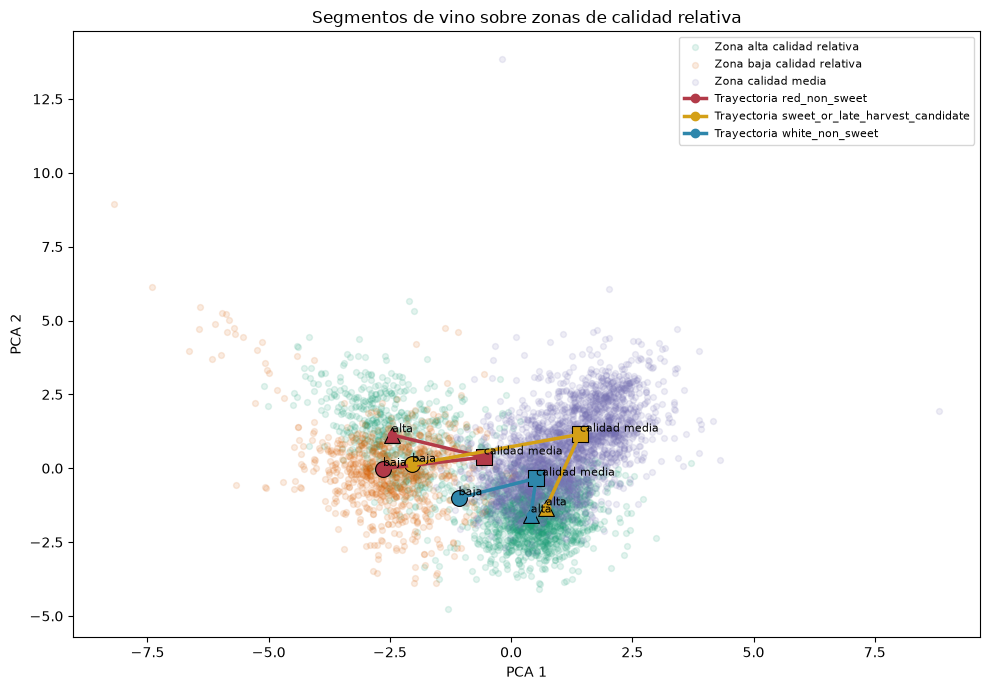

In [32]:
quality_order = ["baja calidad relativa", "calidad media", "alta calidad relativa"]
quality_marker = {
    "baja calidad relativa": "o",
    "calidad media": "s",
    "alta calidad relativa": "^",
}

plt.figure(figsize=(10, 7))

# Fondo: zonas de calidad relativa.
for quality_profile, profile_df in df.groupby("cluster_quality_profile"):
    plt.scatter(
        profile_df["pca_1"],
        profile_df["pca_2"],
        color=quality_profile_colors.get(quality_profile, "gray"),
        alpha=0.12,
        s=18,
        label=f"Zona {quality_profile}"
    )

# Lineas: trayectoria de cada segmento a traves de perfiles de calidad.
centroids = (
    df.groupby(["wine_segment", "cluster_quality_profile"])[["pca_1", "pca_2"]]
    .mean()
    .reset_index()
)

for segment_name, segment_centroids in centroids.groupby("wine_segment"):
    segment_centroids = segment_centroids.copy()
    segment_centroids["quality_order"] = segment_centroids["cluster_quality_profile"].map({
        label: index for index, label in enumerate(quality_order)
    })
    segment_centroids = segment_centroids.sort_values("quality_order")

    plt.plot(
        segment_centroids["pca_1"],
        segment_centroids["pca_2"],
        color=segment_colors.get(segment_name, "gray"),
        linewidth=2.5,
        marker="o",
        label=f"Trayectoria {segment_name}"
    )

    for _, row in segment_centroids.iterrows():
        plt.scatter(
            row["pca_1"],
            row["pca_2"],
            color=segment_colors.get(segment_name, "gray"),
            edgecolor="black",
            linewidth=0.8,
            s=130,
            marker=quality_marker.get(row["cluster_quality_profile"], "o")
        )
        plt.text(
            row["pca_1"],
            row["pca_2"],
            row["cluster_quality_profile"].replace(" calidad relativa", ""),
            fontsize=8,
            ha="left",
            va="bottom"
        )

plt.title("Segmentos de vino sobre zonas de calidad relativa")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

### Validacion cruzada de clusters

Las tablas cruzadas finales responden: **que porcentaje de cada cluster pertenece a cada segmento o tipo real de vino?**

Esto es importante porque el clustering fue no supervisado. El algoritmo no sabia que vino era tinto, blanco o candidato dulce. Si despues vemos que ciertos clusters concentran una categoria, eso significa que la estructura quimica del dataset recupera diferencias reales o analiticamente utiles.

In [33]:
display(pd.crosstab(df["cluster"], df["wine_segment"], normalize="index").round(3))
display(pd.crosstab(df["cluster"], df["type"], normalize="index").round(3))

wine_segment,red_non_sweet,sweet_or_late_harvest_candidate,white_non_sweet
cluster,,,
0,0.002,0.948,0.051
1,0.017,0.380,0.604
2,0.812,0.156,0.031
3,0.920,0.014,0.066
4,0.838,0.127,0.035
5,0.014,0.299,0.687


type,red,white
cluster,,
0,0.003,0.997
1,0.019,0.981
2,0.812,0.188
3,0.934,0.066
4,0.933,0.067
5,0.015,0.985


## Takeaways

1. **Segment first, then compare.** The sugar?acidity rule separates 2.139 candidate sweet / late-harvest profiles from 1.269 non-sweet reds and 1.912 non-sweet whites. This is a practical safeguard against averaging different style logics into one rule.
2. **Chemistry is informative but incomplete.** The best held-out regression result is the Random Forest for non-sweet reds (R? = 0.4518). The available chemistry leaves substantial variation unexplained.
3. **Signals are segment-specific.** Alcohol, density, volatile acidity and sulfur variables do not have one universal interpretation across the three groups; correlations and feature importance need to be read within each segment.
4. **Clusters are descriptive, not causal.** They offer a map of chemical similarity and relative quality profiles, but do not prove that any single variable causes quality.

For a reader who wants to explore the result without running Python, open the [interactive dashboard](./index.html). For an enological or production decision, combine this analysis with tasting, origin, production and style information that are absent from this dataset.
